In [2]:
from pathlib import Path

import seaborn as sns
import squidpy as sq
import scanpy as sc
import anndata as an
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanorama
import harmonypy as hm

sc.logging.print_header()
from shapely.geometry import Polygon, Point

/Users/yangyu/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/yangyu/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yangyu/opt/anaconda3/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


scanpy==1.10.3 anndata==0.10.9 umap==0.5.3 numpy==1.24.4 scipy==1.9.1 pandas==2.2.3 scikit-learn==1.0.2 statsmodels==0.13.2 igraph==0.10.5 pynndescent==0.5.8


In [3]:
## propagate labels from the scRNA-seq dataset to the visium dataset
def label_transfer(dist, labels):
    lab = pd.get_dummies(labels).to_numpy().T
    class_prob = lab @ dist
    norm = np.linalg.norm(class_prob, 2, axis=0)
    class_prob = class_prob / norm
    class_prob = (class_prob.T - class_prob.min(1)) / class_prob.ptp(1)
    return class_prob

In [3]:
## load data
ctrlr0_dir = "/Users/yangyu/Desktop/Harvard_ChenLab/EP/PuLabCtrl_data/Merfish_ctrl/output/region_0/"

ctrl_r0 = sq.read.vizgen(
    path=ctrlr0_dir,
    counts_file="cell_by_gene.csv",
    meta_file="cell_metadata.csv",
    transformation_file="micron_to_mosaic_pixel_transform.csv",
)

## load data
ctrlr1_dir = "/Users/yangyu/Desktop/Harvard_ChenLab/EP/PuLabCtrl_data/Merfish_ctrl/output/region_1/"

ctrl_r1 = sq.read.vizgen(
    path=ctrlr1_dir,
    counts_file="cell_by_gene.csv",
    meta_file="cell_metadata.csv",
    transformation_file="micron_to_mosaic_pixel_transform.csv",
)

## load data
ctrlr2_dir = "/Users/yangyu/Desktop/Harvard_ChenLab/EP/PuLabCtrl_data/Merfish_ctrl/output/region_2/"

ctrl_r2 = sq.read.vizgen(
    path=ctrlr2_dir,
    counts_file="cell_by_gene.csv",
    meta_file="cell_metadata.csv",
    transformation_file="micron_to_mosaic_pixel_transform.csv",
)

In [4]:
## load data
efer1_dir = "/Users/yangyu/Desktop/Harvard_ChenLab/EP/EFE_data/Mer2_EFE/output/region_1/"

efe_r1 = sq.read.vizgen(
    path=efer1_dir,
    counts_file="cell_by_gene.csv",
    meta_file="cell_metadata.csv",
    transformation_file="micron_to_mosaic_pixel_transform.csv",
)

## load data
efer2_dir = "/Users/yangyu/Desktop/Harvard_ChenLab/EP/EFE_data/Mer2_EFE/output/region_2/"

efe_r2 = sq.read.vizgen(
    path=efer2_dir,
    counts_file="cell_by_gene.csv",
    meta_file="cell_metadata.csv",
    transformation_file="micron_to_mosaic_pixel_transform.csv",
)

In [5]:
## filter unwanted cells unnecessary for the control replicates
#polygon_vertices_ctrl_r0 = [(-40.5, 7232), (558, 5718), (1473, 4413), (3648, 2960),(4327, 2951), (5993, 5944), (7153, 10524), (2831, 11403)]
#polygon_ctrl_r0 = Polygon(polygon_vertices_ctrl_r0)

## Extract spatial coordinates
#x_coords_ctrl_r0 = ctrl_r0.obs['min_x']
#y_coords_ctrl_r0 = ctrl_r0.obs['min_y']

## Check if each cell is within the polygon
#roi_mask_ctrl_r0 = [polygon_ctrl_r0.contains(Point(x, y)) for x, y in zip(x_coords_ctrl_r0, y_coords_ctrl_r0)]

## Subset the AnnData object
#ctrl_r0 = ctrl_r0[roi_mask_ctrl_r0, :]



## filter unwanted cells
#polygon_vertices_ctrl_r1 = [(8081, 10249), (8512, 9942), (9173, 10172), (11152, 10974),(12705, 9055), (12374, 6725), (7561, 6989), (7202, 7675)]
#polygon_ctrl_r1 = Polygon(polygon_vertices_ctrl_r1)

## Extract spatial coordinates
#x_coords_ctrl_r1 = ctrl_r1.obs['min_x']
#y_coords_ctrl_r1 = ctrl_r1.obs['min_y']

## Check if each cell is within the polygon
#roi_mask_ctrl_r1 = [polygon_ctrl_r1.contains(Point(x, y)) for x, y in zip(x_coords_ctrl_r1, y_coords_ctrl_r1)]

## Subset the AnnData object
#ctrl_r1 = ctrl_r1[roi_mask_ctrl_r1, :]



## filter unwanted cells
#polygon_vertices_ctrl_r2 = [(5254, 1989), (6525, 4163), (10442, 5036), (13430, 3049),(12589, 563), (8021, 551), (7557, 36), (6358, -15)]
#polygon_ctrl_r2 = Polygon(polygon_vertices_ctrl_r2)

## Extract spatial coordinates
#x_coords_ctrl_r2 = ctrl_r2.obs['min_x']
#y_coords_ctrl_r2 = ctrl_r2.obs['min_y']

## Check if each cell is within the polygon
#roi_mask_ctrl_r2 = [polygon_ctrl_r2.contains(Point(x, y)) for x, y in zip(x_coords_ctrl_r2, y_coords_ctrl_r2)]

## Subset the AnnData object
#ctrl_r2 = ctrl_r2[roi_mask_ctrl_r2, :]

In [6]:
## filter unwanted cells only necessary for EFE r2
#polygon_vertices_efe_r1 = [(6469, 11956), (6736, 7193), (3353, 8513), (6021, 7998)]
#polygon_efe_r1 = Polygon(polygon_vertices_efe_r1)

## Extract spatial coordinates
#x_coords_efe_r1 = efe_r1.obs['min_x']
#y_coords_efe_r1 = efe_r1.obs['min_y']

## Check if each cell is within the polygon
#roi_mask_efe_r1 = [polygon_efe_r1.contains(Point(x, y)) for x, y in zip(x_coords_efe_r1, y_coords_efe_r1)]

## Subset the AnnData object
#efe_r1 = efe_r1[roi_mask_efe_r1, :]



## filter unwanted cells
polygon_vertices_efe_r2 = [(8000, 1195), (11140, 3070), (13038, 4899), (13230, 7510),(13206, 7995), (12226, 10404),(10336, 11445), (10016, 11200),(8852, 9396), (4745, 1715),(4495, 2),(8012, 1208)]
polygon_efe_r2 = Polygon(polygon_vertices_efe_r2)

## Extract spatial coordinates
x_coords_efe_r2 = efe_r2.obs['min_x']
y_coords_efe_r2 = efe_r2.obs['min_y']

## Check if each cell is within the polygon
roi_mask_efe_r2 = [polygon_efe_r2.contains(Point(x, y)) for x, y in zip(x_coords_efe_r2, y_coords_efe_r2)]

## Subset the AnnData object
efe_r2 = efe_r2[roi_mask_efe_r2, :]

polygon_vertices = [(10010, 6574), (10587, 7282), (10486, 5962), (9939, 6218)]
polygon = Polygon(polygon_vertices)

x_coords = efe_r2.obs['min_x']
y_coords = efe_r2.obs['min_y']

## Invert the mask to exclude cells within the polygon
roi_mask = [polygon.contains(Point(x, y)) for x, y in zip(x_coords, y_coords)]
exclude_mask = [not inside for inside in roi_mask]

## Subset the AnnData object to exclude cells within the polygon
efe_r2 = efe_r2[exclude_mask, :]

In [7]:
## check
#ctrl_r0
#ctrl_r1
#ctrl_r2
#efe_r1
#efe_r2

In [7]:
## make unique labels
ctrl_r0.var_names_make_unique()
ctrl_r1.var_names_make_unique()
ctrl_r2.var_names_make_unique()
efe_r1.var_names_make_unique()
efe_r2.var_names_make_unique()

In [8]:
## calculate qc matrices
sc.pp.calculate_qc_metrics(ctrl_r0, percent_top=(50, 100, 200, 300), inplace=True)
sc.pp.calculate_qc_metrics(ctrl_r1, percent_top=(50, 100, 200, 300), inplace=True)
sc.pp.calculate_qc_metrics(ctrl_r2, percent_top=(50, 100, 200, 300), inplace=True)
sc.pp.calculate_qc_metrics(efe_r1, percent_top=(50, 100, 200, 300), inplace=True)
sc.pp.calculate_qc_metrics(efe_r2, percent_top=(50, 100, 200, 300), inplace=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [9]:
## blank genes
ctrl_r0.obsm["blank_genes"].to_numpy().sum() / ctrl_r0.var["total_counts"].sum() * 100
ctrl_r1.obsm["blank_genes"].to_numpy().sum() / ctrl_r1.var["total_counts"].sum() * 100
ctrl_r2.obsm["blank_genes"].to_numpy().sum() / ctrl_r2.var["total_counts"].sum() * 100
efe_r1.obsm["blank_genes"].to_numpy().sum() / efe_r1.var["total_counts"].sum() * 100
efe_r2.obsm["blank_genes"].to_numpy().sum() / efe_r2.var["total_counts"].sum() * 100

0.5562007892876863

In [10]:
ctrl_r0.obs["library_id"] = "ctrl_r0"
ctrl_r1.obs["library_id"] = "ctrl_r1"
ctrl_r2.obs["library_id"] = "ctrl_r2"

efe_r1.obs["library_id"] = "efe_r1"
efe_r2.obs["library_id"] = "efe_r2"

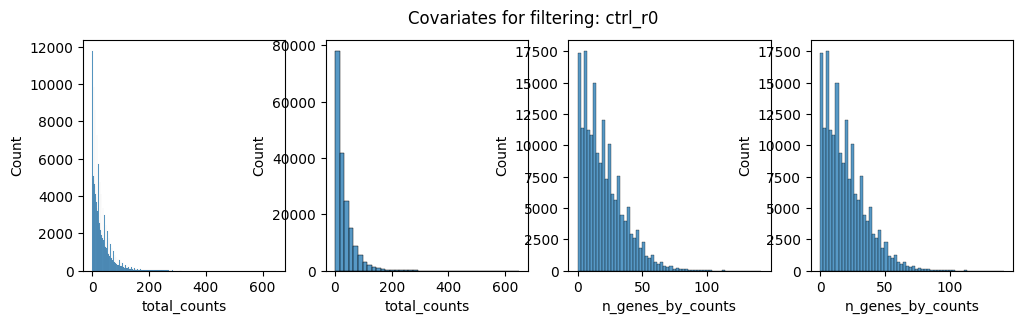

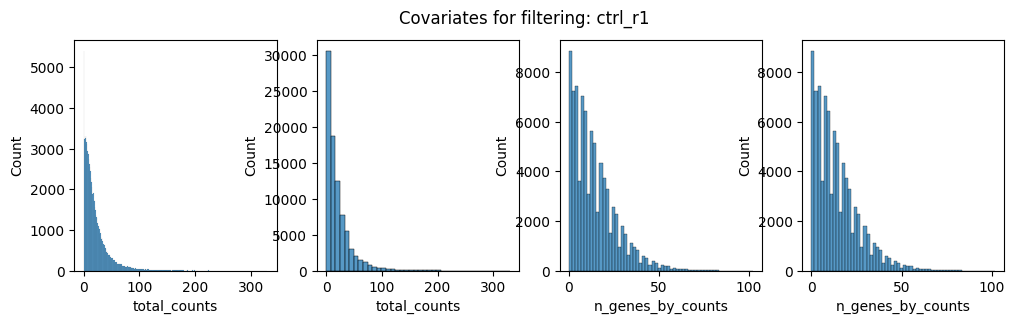

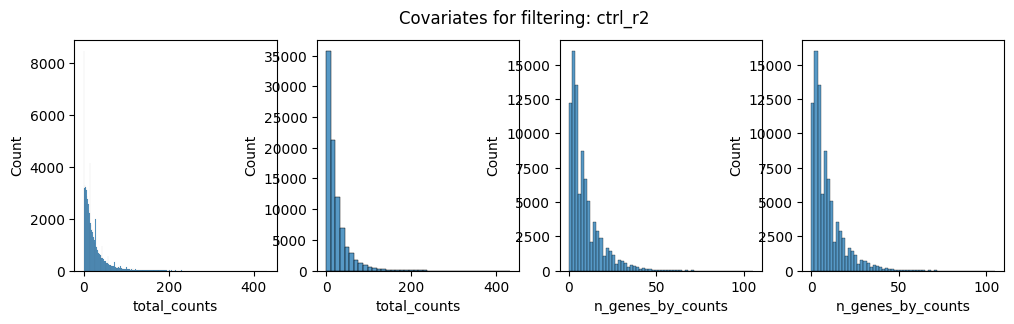

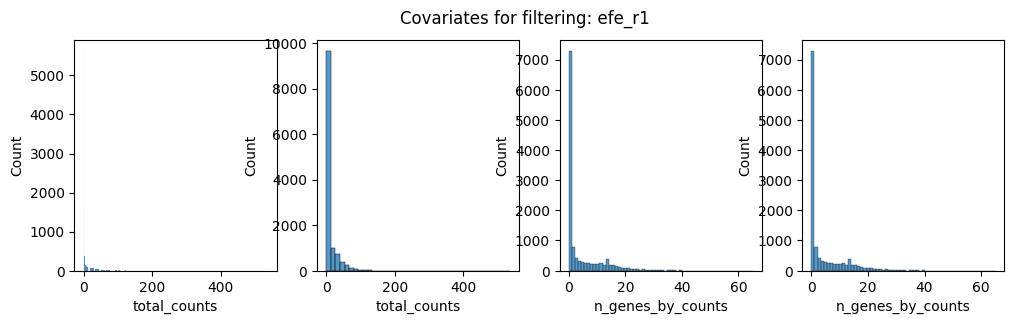

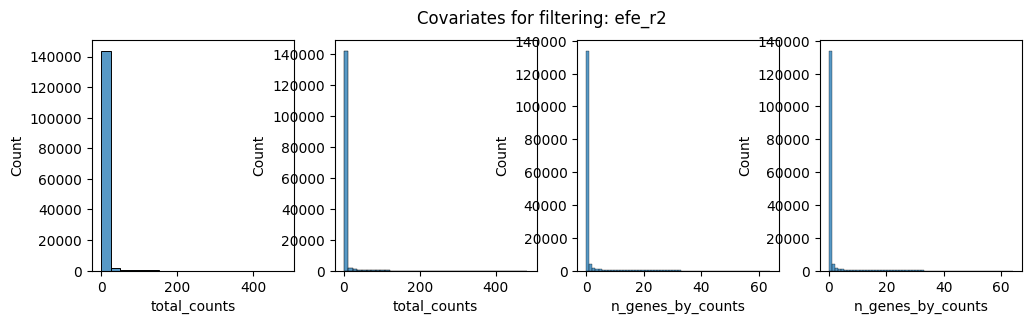

In [11]:
## Next we plot the distribution of total transcripts per cell, 
## unique transcripts per cell, transcripts per FOV and the volume of the segmented cells
for name, adata in [
    ("ctrl_r0", ctrl_r0),
    ("ctrl_r1", ctrl_r1),
    ("ctrl_r2", ctrl_r2),
    ("efe_r1", efe_r1),
    ("efe_r2", efe_r2),
]:
    fig, axs = plt.subplots(1, 4, figsize=(12, 3))
    fig.suptitle(f"Covariates for filtering: {name}")

    sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
    sns.histplot(
        adata.obs["total_counts"][adata.obs["total_counts"] < 20000],
        kde=False,
        bins=40,
        ax=axs[1],
    )
    sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
    sns.histplot(
        adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 4000],
        kde=False,
        bins=60,
        ax=axs[3],
    )

In [12]:
## All cells that do not contain at least 10 transcripts are filtered out with
sc.pp.filter_cells(ctrl_r0, min_counts=10)
sc.pp.filter_cells(ctrl_r1, min_counts=10)
sc.pp.filter_cells(ctrl_r2, min_counts=10)

sc.pp.filter_cells(efe_r1, min_counts=5)
sc.pp.filter_cells(efe_r2, min_counts=5)

In [13]:
## filter by cell volume
# Define min and max volume thresholds
min_volume = 50
max_volume = 2500

ctrl_r0 = ctrl_r0[ctrl_r0.obs["volume"] >= min_volume, :].copy()
ctrl_r0 = ctrl_r0[ctrl_r0.obs["volume"] < max_volume, :].copy()

ctrl_r1 = ctrl_r1[ctrl_r1.obs["volume"] >= min_volume, :].copy()
ctrl_r1 = ctrl_r1[ctrl_r1.obs["volume"] < max_volume, :].copy()

ctrl_r2 = ctrl_r2[ctrl_r2.obs["volume"] >= min_volume, :].copy()
ctrl_r2 = ctrl_r2[ctrl_r2.obs["volume"] < max_volume, :].copy()

efe_r1 = efe_r1[efe_r1.obs["volume"] >= min_volume, :].copy()
efe_r1 = efe_r1[efe_r1.obs["volume"] < max_volume, :].copy()

efe_r2 = efe_r2[efe_r2.obs["volume"] >= min_volume, :].copy()
efe_r2 = efe_r2[efe_r2.obs["volume"] < max_volume, :].copy()

In [3]:
## check
#ctrl_r0
#ctrl_r1
#ctrl_r2
#efe_r1
#efe_r2

In [21]:
## normalization process by total
for adata in [
    ctrl_r0,
    ctrl_r1,
    ctrl_r2,
    efe_r1,
    efe_r2,
]:
    adata.layers["counts"] = adata.X.copy()
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="counts",inplace=True)
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.scale(adata, max_value=10)

In [4]:
#print(np.array(ctrl_r1.layers["counts"]))

In [22]:
## check
ctrl_r1.X.max()

10.0

In [18]:
## load snRNAseq data and perform label transfer for each replicate individually
#https://scanpy-tutorials.readthedocs.io/en/latest/spatial/integration-scanorama.html

In [26]:
## load the RNA data
adata_cortex = sc.read("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/rna_only/inte_12samp/Integrated12samp_combined_grandannt_010424.h5ad")

In [27]:
## take a look at the data
adata_cortex.obs.Cell_Type.unique()

array(['EC_E1', 'SMC', 'EC', 'FB', 'PeriC', 'CM', 'Macrophage', 'EndoC',
       'EC_E3', 'T-cell', 'Neuro', 'Mast-cell'], dtype=object)

In [28]:
## Run integration with Scanorama for each sample separately
adatas_rna_ctrl_r0 = [adata_cortex, ctrl_r0]
adatas_rna_ctrl_r1 = [adata_cortex, ctrl_r1]
adatas_rna_ctrl_r2 = [adata_cortex, ctrl_r2]
adatas_rna_efe_r1 = [adata_cortex, efe_r1]
adatas_rna_efe_r2 = [adata_cortex, efe_r2]


# Integration.
adatas_cor_ctrl_r0 = scanorama.correct_scanpy(adatas_rna_ctrl_r0, return_dimred=True)
adatas_cor_ctrl_r1 = scanorama.correct_scanpy(adatas_rna_ctrl_r1, return_dimred=True)
adatas_cor_ctrl_r2 = scanorama.correct_scanpy(adatas_rna_ctrl_r2, return_dimred=True)
adatas_cor_efe_r1 = scanorama.correct_scanpy(adatas_rna_efe_r1, return_dimred=True)
adatas_cor_efe_r2 = scanorama.correct_scanpy(adatas_rna_efe_r2, return_dimred=True)

Found 477 genes among all datasets
[[0.         0.13359933]
 [0.         0.        ]]
Processing datasets (0, 1)
Found 477 genes among all datasets
[[0.         0.13834569]
 [0.         0.        ]]
Processing datasets (0, 1)
Found 477 genes among all datasets
[[0.         0.12309505]
 [0.         0.        ]]
Processing datasets (0, 1)
Found 477 genes among all datasets
[[0.         0.47252747]
 [0.         0.        ]]
Processing datasets (0, 1)
Found 477 genes among all datasets
[[0.         0.39092837]
 [0.         0.        ]]
Processing datasets (0, 1)


In [29]:
## assign integrated embeddings to objects
adata_rna_ctrl_r0 = sc.concat(
    adatas_cor_ctrl_r0,
    label="dataset",
    keys=["snRNA", "vigzen"],
    join="outer",
    uns_merge="first",
)
adata_rna_ctrl_r1 = sc.concat(
    adatas_cor_ctrl_r1,
    label="dataset",
    keys=["snRNA", "vigzen"],
    join="outer",
    uns_merge="first",
)
adata_rna_ctrl_r2 = sc.concat(
    adatas_cor_ctrl_r2,
    label="dataset",
    keys=["snRNA", "vigzen"],
    join="outer",
    uns_merge="first",
)

adata_rna_efe_r1 = sc.concat(
    adatas_cor_efe_r1,
    label="dataset",
    keys=["snRNA", "vigzen"],
    join="outer",
    uns_merge="first",
)
adata_rna_efe_r2 = sc.concat(
    adatas_cor_efe_r2,
    label="dataset",
    keys=["snRNA", "vigzen"],
    join="outer",
    uns_merge="first",
)

In [30]:
## compute cosine distances between the visium dataset and the scRNA-seq dataset
from sklearn.metrics.pairwise import cosine_distances

distances_ctrlr0 = 1 - cosine_distances(
    adata_rna_ctrl_r0[adata_rna_ctrl_r0.obs.dataset == "snRNA"].obsm[
        "X_scanorama"
    ],
    adata_rna_ctrl_r0[adata_rna_ctrl_r0.obs.dataset == "vigzen"].obsm[
        "X_scanorama"
    ],
)
distances_ctrlr1 = 1 - cosine_distances(
    adata_rna_ctrl_r1[adata_rna_ctrl_r1.obs.dataset == "snRNA"].obsm[
        "X_scanorama"
    ],
    adata_rna_ctrl_r1[adata_rna_ctrl_r1.obs.dataset == "vigzen"].obsm[
        "X_scanorama"
    ],
)

In [24]:
## compute cosine distances between the visium dataset and the scRNA-seq dataset
distances_ctrlr2 = 1 - cosine_distances(
    adata_rna_ctrl_r2[adata_rna_ctrl_r2.obs.dataset == "snRNA"].obsm[
        "X_scanorama"
    ],
    adata_rna_ctrl_r2[adata_rna_ctrl_r2.obs.dataset == "vigzen"].obsm[
        "X_scanorama"
    ],
)

distances_efer1 = 1 - cosine_distances(
    adata_rna_efe_r1[adata_rna_efe_r1.obs.dataset == "snRNA"].obsm[
        "X_scanorama"
    ],
    adata_rna_efe_r1[adata_rna_efe_r1.obs.dataset == "vigzen"].obsm[
        "X_scanorama"
    ],
)
distances_efer2 = 1 - cosine_distances(
    adata_rna_efe_r2[adata_rna_efe_r2.obs.dataset == "snRNA"].obsm[
        "X_scanorama"
    ],
    adata_rna_efe_r2[adata_rna_efe_r2.obs.dataset == "vigzen"].obsm[
        "X_scanorama"
    ],
)

In [25]:
## propagate labels from the scRNA-seq dataset to the vizgen dataset
def label_transfer(dist, labels):
    lab = pd.get_dummies(labels).to_numpy().T
    class_prob = lab @ dist
    norm = np.linalg.norm(class_prob, 2, axis=0)
    class_prob = class_prob / norm
    class_prob = (class_prob.T - class_prob.min(1)) / class_prob.ptp(1)
    return class_prob

In [26]:
## calculate transfer prob with label transfer
class_prob_ctrl_r0 = label_transfer(distances_ctrlr0, adata_cortex.obs.Cell_Type)
class_prob_ctrl_r1 = label_transfer(distances_ctrlr1, adata_cortex.obs.Cell_Type)
class_prob_ctrl_r2 = label_transfer(distances_ctrlr2, adata_cortex.obs.Cell_Type)
class_prob_efe_r1 = label_transfer(distances_efer1, adata_cortex.obs.Cell_Type)
class_prob_efe_r2 = label_transfer(distances_efer2, adata_cortex.obs.Cell_Type)
adata_cortex.obs["Cell_Type"] = adata_cortex.obs["Cell_Type"].astype("category")
#adata_cortex.obs["Cell_Type"] = adata_cortex.obs["Cell_Type"].astype("category")

In [27]:
#efe_r1.obs.index
#class_prob_ctrl_r0

In [28]:
## convert the class_prob_[anterior-posterior] object to a dataframe and assign it to the respective anndata
cp_ctrl_r0_df = pd.DataFrame(
    class_prob_ctrl_r0,
    columns=sorted(adata_cortex.obs["Cell_Type"].cat.categories),
)
cp_ctrl_r1_df = pd.DataFrame(
    class_prob_ctrl_r1,
    columns=sorted(adata_cortex.obs["Cell_Type"].cat.categories),
)
cp_ctrl_r2_df = pd.DataFrame(
    class_prob_ctrl_r2,
    columns=sorted(adata_cortex.obs["Cell_Type"].cat.categories),
)


cp_efe_r1_df = pd.DataFrame(
    class_prob_efe_r1,
    columns=sorted(adata_cortex.obs["Cell_Type"].cat.categories),
)
cp_efe_r2_df = pd.DataFrame(
    class_prob_efe_r2,
    columns=sorted(adata_cortex.obs["Cell_Type"].cat.categories),
)

cp_ctrl_r0_df.index = ctrl_r0.obs.index
cp_ctrl_r1_df.index = ctrl_r1.obs.index
cp_ctrl_r2_df.index = ctrl_r2.obs.index

cp_efe_r1_df.index = efe_r1.obs.index
cp_efe_r2_df.index = efe_r2.obs.index

In [29]:
#sorted_df = cp_efe_r2_df.sort_values(by="EC_E1", ascending=False)
#print(sorted_df)

In [30]:
## transfer labels
ctrl_r0_transfer = ctrl_r0.copy()
ctrl_r0_transfer.obs = pd.concat(
    [ctrl_r0.obs, cp_ctrl_r0_df], axis=1
)

ctrl_r1_transfer = ctrl_r1.copy()
ctrl_r1_transfer.obs = pd.concat(
    [ctrl_r1.obs, cp_ctrl_r1_df], axis=1
)

ctrl_r2_transfer = ctrl_r2.copy()
ctrl_r2_transfer.obs = pd.concat(
    [ctrl_r2.obs, cp_ctrl_r2_df], axis=1
)

efe_r1_transfer = efe_r1.copy()
efe_r1_transfer.obs = pd.concat(
    [efe_r1.obs, cp_efe_r1_df], axis=1
)

efe_r2_transfer = efe_r2.copy()
efe_r2_transfer.obs = pd.concat(
    [efe_r2.obs, cp_efe_r2_df], axis=1
)

In [31]:
## visualize
#efe_r1_transfer.obs

# Dictionary of DataFrames (replace with your actual DataFrames)
df_dict = {
    'efe_r1_transfer_obs': efe_r1_transfer.obs,
    'efe_r2_transfer_obs': efe_r2_transfer.obs,
    'ctrl_r0_transfer_obs': ctrl_r0_transfer.obs,
    'ctrl_r1_transfer_obs': ctrl_r1_transfer.obs,
    'ctrl_r2_transfer_obs': ctrl_r2_transfer.obs
}

# List to store processed DataFrames
processed_dfs = []

# Process each DataFrame
for df_name, df in df_dict.items():
    # Extract the sample ID from the DataFrame name
    sample_id = '_'.join(df_name.split('_')[:2])  # First two elements separated by '_'
    
    # Add the sample ID as a new column
    df['sample_id'] = sample_id
    
    # Append the processed DataFrame to the list
    processed_dfs.append(df)

# Combine all DataFrames into one
combined_df = pd.concat(processed_dfs, ignore_index=True)

combined_df

# Export the combined DataFrame to a CSV file
#combined_df.to_csv('/Users/yangyu/Desktop/merged_predlabel_5samps_070825.csv', index=False)

In [32]:
## leiden for each sample
for adata in [
    ctrl_r0_transfer,
    ctrl_r1_transfer,
    ctrl_r2_transfer,
    efe_r1_transfer,
    efe_r2_transfer,
]:

    # List of target column names (e.g., cell types)
    target_cols = adata_cortex.obs.Cell_Type.unique()  # Unique cell types from adata_cortex

    missing_cols = [col for col in target_cols if col not in adata.obs.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in adata.obs: {missing_cols}")

    # Find the column name with the largest value in each row
    adata.obs['pred_celltype'] = adata.obs[target_cols].idxmax(axis=1)
    adata.obs['pred_celltype'] = pd.Categorical(adata.obs['pred_celltype'])

In [33]:
## save
#ctrl_r0_transfer.write("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/ctrl_r0_labeltransed_070825.h5ad")
#ctrl_r1_transfer.write("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/ctrl_r1_labeltransed_070825.h5ad")
#ctrl_r2_transfer.write("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/ctrl_r2_labeltransed_070825.h5ad")
#efe_r1_transfer.write("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/efe_r1_labeltransed_070825.h5ad")
#efe_r2_transfer.write("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/efe_r2_labeltransed_070825.h5ad")

In [31]:
## load label transfered data
ctrl_r1_transfer = sc.read("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/ctrl_r0_labeltransed_070825.h5ad")
ctrl_r2_transfer = sc.read("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/ctrl_r1_labeltransed_070825.h5ad")
ctrl_r3_transfer = sc.read("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/ctrl_r2_labeltransed_070825.h5ad")
efe_r1_transfer = sc.read("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/efe_r1_labeltransed_070825.h5ad")
efe_r2_transfer = sc.read("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/efe_r2_labeltransed_070825.h5ad")

In [32]:
## assign adata by each replicate
adata = efe_r1_transfer

In [33]:
# Modify names due to older version of namings
#adata.obs.rename(columns={'EC': 'EC_1'}, inplace=True)
#adata.obs.rename(columns={'EC_E1': 'EC_2'}, inplace=True)
#adata.obs.rename(columns={'EC_E3': 'EC_3'}, inplace=True)
#adata.obs["pred_celltype"] = adata.obs["pred_celltype"].replace("EC", "EC_1")
#adata.obs["pred_celltype"] = adata.obs["pred_celltype"].replace("EC_E1", "EC_2")
#adata.obs["pred_celltype"] = adata.obs["pred_celltype"].replace("EC_E3", "EC_3")

/var/folders/rw/46x0v_l533l7bpj7q_fy70_40000gn/T/ipykernel_76611/1738143404.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["pred_celltype"] = adata.obs["pred_celltype"].replace("EC", "EC_1")
/var/folders/rw/46x0v_l533l7bpj7q_fy70_40000gn/T/ipykernel_76611/1738143404.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["pred_celltype"] = adata.obs["pred_celltype"].replace("EC_E1", "EC_2")
/var/folders/rw/46x0v_l533l7bpj7q_fy70_40000gn/T/ipykernel_76611/1738143404.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) wit

In [34]:
percentages = adata.obs["pred_celltype"].value_counts(normalize=True) * 100

# Display results
print("Percentage of each cell type:")
print(percentages.round(2))  # Rounded to 2 decimal places

Percentage of each cell type:
pred_celltype
FB            44.84
EC_3          27.72
EC_1           8.57
T-cell         6.41
CM             2.51
PeriC          2.32
Neuro          2.14
EndoC          1.85
EC_2           1.60
Macrophage     0.94
SMC            0.72
Mast-cell      0.38
Name: proportion, dtype: float64


In [35]:
## define colors
import squidpy as sq
import seaborn as sns

import squidpy as sq
import matplotlib.pyplot as plt

# Define a fixed custom color palette for 12 cell types
custom_colors = {
    "CM": "#DC143C",
    "EC_1": "#FFA500",        
    "EC_2": "#00BFFF",     
    "EC_3": "#DDA0DD",     
    "EndoC": "#FF69B4",     
    "FB": "#6A5ACD",        
    "Macrophage": "#8FBC8F",
    "Mast-cell": "#C71585", 
    "Neuro": "#A0522D",     
    "PeriC": "#DB7093",     
    "SMC": "#9932CC",       
    "T-cell": "#87CEFA"     
}

# Get unique cell types in adata.obs["pred_celltype"]
unique_celltypes = sorted(adata.obs["pred_celltype"].unique())

# Ensure all unique cell types have a corresponding color
missing_celltypes = [celltype for celltype in unique_celltypes if celltype not in custom_colors]
if missing_celltypes:
    raise ValueError(f"Missing color mappings for the following cell types: {missing_celltypes}")

# Assign colors to `adata.uns`
adata.uns["pred_celltype_colors"] = [custom_colors[celltype] for celltype in unique_celltypes]

In [36]:
## compute neighbors
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
sq.gr.centrality_scores(adata, cluster_key="pred_celltype")

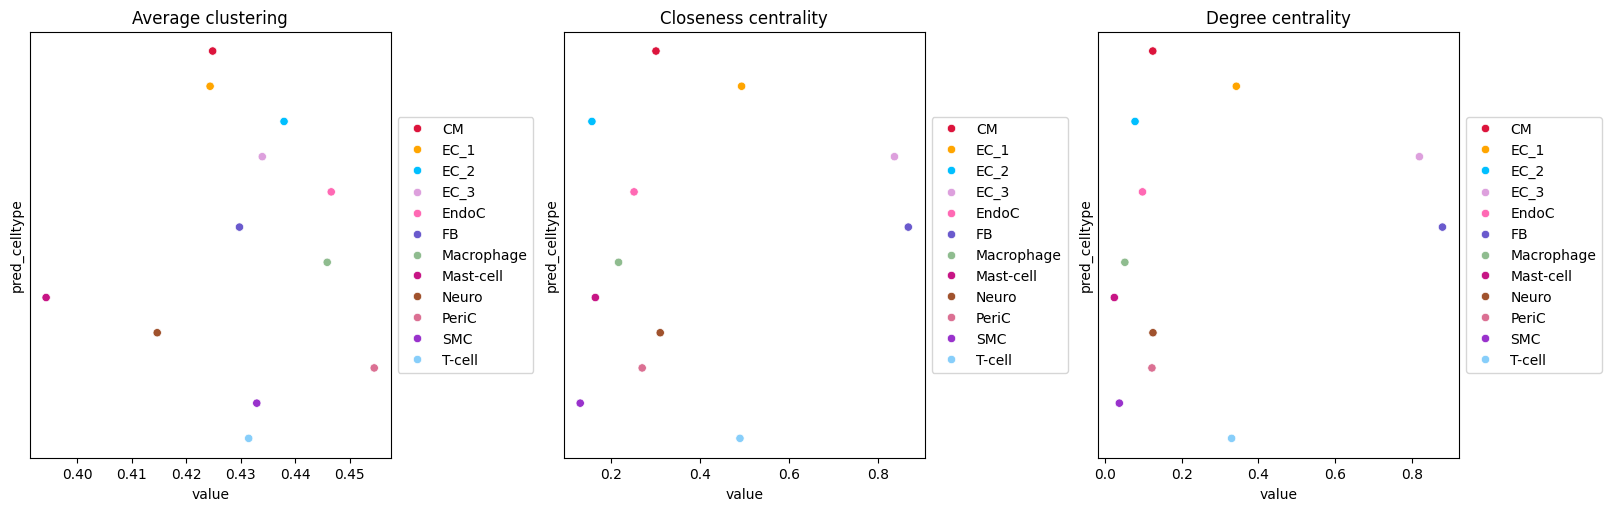

In [37]:
## centrality scores
sq.pl.centrality_scores(adata, cluster_key="pred_celltype", figsize=(16, 5))

#closeness centrality - measure of how close the group is to other nodes.

#clustering coefficient - measure of the degree to which nodes cluster together.

#degree centrality - fraction of non-group members connected to group members.



In [38]:
# Step 1: Extract the centrality scores
centrality_df = pd.DataFrame(adata.uns['pred_celltype_centrality_scores'])

# Step 3: Display the DataFrame
print(centrality_df)

            degree_centrality  average_clustering  closeness_centrality
CM                   0.124960            0.424861              0.300726
EC_1                 0.342376            0.424394              0.493058
EC_2                 0.078813            0.437955              0.156841
EC_3                 0.818853            0.433965              0.836483
EndoC                0.098209            0.446610              0.251488
FB                   0.878771            0.429783              0.867654
Macrophage           0.052298            0.445873              0.216690
Mast-cell            0.024898            0.394318              0.164532
Neuro                0.125441            0.414694              0.310273
PeriC                0.122790            0.454494              0.269748
SMC                  0.037951            0.432954              0.130532
T-cell               0.330091            0.431470              0.489411


In [39]:
## save
#centrality_df.to_csv("/Users/yangyu/Desktop/Harvard_ChenLab/EP/Intermediates/Merfish/processed/files/efe_r1_centrescore_070825.csv")

In [40]:
## enrichment analysis
sq.gr.nhood_enrichment(adata, cluster_key="pred_celltype", n_perms=1000)

  0%|          | 0/1000 [00:00<?, ?/s]

/Users/yangyu/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/yangyu/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/yangyu/opt/anaconda3/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [41]:
#print("Available keys in 'pred_celltype_nhood_enrichment':", adata.uns.keys())

In [42]:
unique_celltypes

['CM',
 'EC_1',
 'EC_2',
 'EC_3',
 'EndoC',
 'FB',
 'Macrophage',
 'Mast-cell',
 'Neuro',
 'PeriC',
 'SMC',
 'T-cell']

In [43]:
# Extract the zscore matrix
# Convert to DataFrame
zscore_df = pd.DataFrame(adata.uns['pred_celltype_nhood_enrichment']['zscore'])

# Display the DataFrame
print(zscore_df)

## save for each sample
#zscore_df.to_csv("/Users/yangyu/Desktop/efe_r1_nenrichment_070825.csv")

          0          1         2         3         4         5         6   \
0   8.123221   5.721876 -0.252860 -1.607778 -1.381374 -4.714814 -0.758194   
1   5.721876  11.540888  1.144842 -1.749642 -2.186544 -8.381019 -1.747252   
2  -0.252860   1.144842  3.591613  1.221601 -1.524366 -3.587101  0.655314   
3  -1.607778  -1.749642  1.221601  1.213096 -1.250241 -1.570356  1.286693   
4  -1.381374  -2.186544 -1.524366 -1.250241  0.479743  2.251865 -1.234269   
5  -4.714814  -8.381019 -3.587101 -1.570356  2.251865  6.193733 -0.974783   
6  -0.758194  -1.747252  0.655314  1.286693 -1.234269 -0.974783  2.500988   
7   0.139404   1.542253 -1.113248 -0.676872 -1.198763  1.992589 -0.869115   
8   0.847091   0.369402 -0.610068  2.848560 -0.131607 -1.016646 -0.910204   
9   1.782947   4.815839  1.121639 -1.642624 -1.599934 -2.587182 -0.570862   
10 -1.917625  -0.549482  4.693660  1.721544  1.021796 -2.348885 -0.267113   
11  1.719832   0.530045 -0.568278  0.035882 -0.557715  0.378549  1.630722   

In [44]:
# Access the z-score matrix
from scipy.stats import norm

zscore = adata.uns['pred_celltype_nhood_enrichment']['zscore']

# Compute p-values from z-scores (two-tailed test)
pvalues_recomputed = 2 * (1 - norm.cdf(np.abs(zscore)))

# Convert to a pandas DataFrame for better readability (optional)
pvalues_recomputed_df = pd.DataFrame(pvalues_recomputed, index=adata.uns['pred_celltype_nhood_enrichment'].get('index', None), columns=adata.uns['pred_celltype_nhood_enrichment'].get('index', None))

# Display the recomputed p-values
print(pvalues_recomputed_df)

## save
#pvalues_recomputed_df.to_csv("/Users/yangyu/Desktop/efe_r1_enrichmentp_070825.csv")

              0             1         2         3         4             5   \
0   4.440892e-16  1.053542e-08  0.800376  0.107884  0.167164  2.419311e-06   
1   1.053542e-08  0.000000e+00  0.252275  0.080180  0.028776  0.000000e+00   
2   8.003760e-01  2.522748e-01  0.000329  0.221859  0.127417  3.343749e-04   
3   1.078838e-01  8.018015e-02  0.221859  0.225093  0.211212  1.163323e-01   
4   1.671640e-01  2.877585e-02  0.127417  0.211212  0.631410  2.433080e-02   
5   2.419311e-06  0.000000e+00  0.000334  0.116332  0.024331  5.875580e-10   
6   4.483350e-01  8.059372e-02  0.512265  0.198201  0.217103  3.296681e-01   
7   8.891308e-01  1.230121e-01  0.265602  0.498487  0.230620  4.630646e-02   
8   3.969442e-01  7.118279e-01  0.541817  0.004392  0.895295  3.093219e-01   
9   7.459486e-02  1.465824e-06  0.262016  0.100461  0.109613  9.676439e-03   
10  5.515862e-02  5.826749e-01  0.000003  0.085152  0.306877  1.882971e-02   
11  8.546303e-02  5.960806e-01  0.569847  0.971377  0.577039  7.

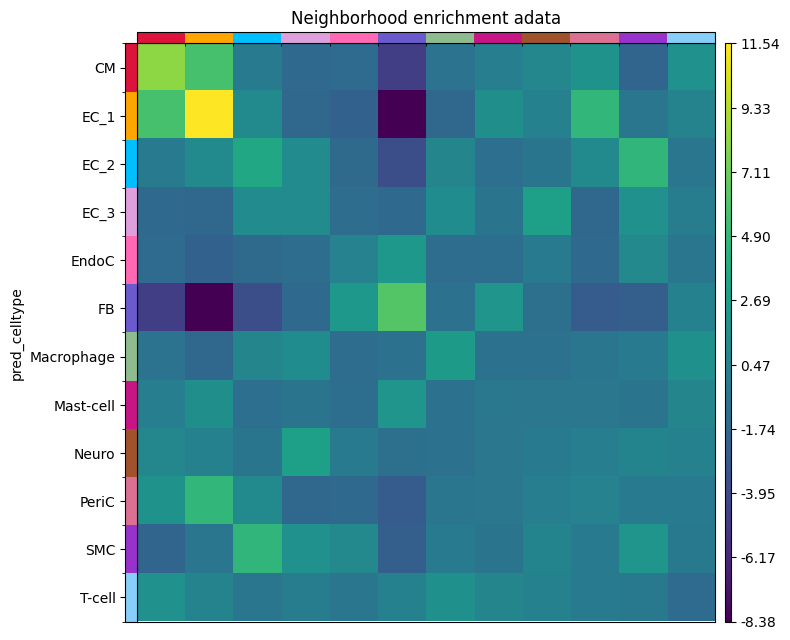

In [55]:
## visualize individual
fig, ax = plt.subplots(figsize=(8, 8))  # size can be adjusted

# Plot neighborhood enrichment on this axis
sq.pl.nhood_enrichment(
    adata,
    cluster_key="pred_celltype",
    title="Neighborhood enrichment adata",
    ax=ax
)

plt.tight_layout()
plt.show()

/Users/yangyu/opt/anaconda3/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


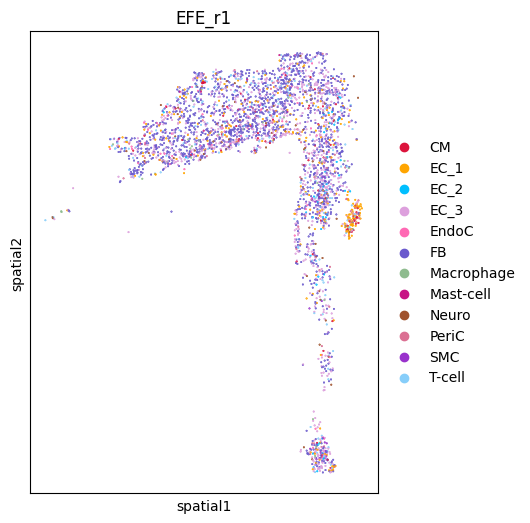

In [56]:
# Create a figure and axis correctly
fig, ax = plt.subplots(figsize=(8, 6))  # Use a single Axes object

# Ensure `ax` is correctly passed
sq.pl.spatial_scatter(
    adata, 
    color="pred_celltype", 
    shape=None, 
    size=0.5, 
    ax=ax  # Fix: Ensure `ax` is a single axis
)

# Optional: Set a title if needed
ax.set_title("EFE_r1")  

# save
#plt.savefig("/Users/yangyu/Desktop/EFE_r1_spatial_celltypes.pdf", 
           #bbox_inches='tight',  # Ensures no content is cut off
           #dpi=300,  # High resolution
           #format='pdf')

plt.show()  # Display the plot
#ax.axis('off')  # Turn off axes if not needed

#sq.pl.spatial_scatter(adata, color="pred_celltype", shape=None, size=0.5, ax=ax[1])